Преобразование Фурье.
1. Преобразовать исходный генератор данных. Добавить возможность добавления периодического шума.
2. Удалить периодический шум при помощи преобразования Фурье.
3. Измерить показатели качества при помощи преобразования Фурье.

Dataset: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask

In [1]:
import os
import math
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as v2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import numpy as np
import cv2
import json
import itertools
from scipy.signal import find_peaks

In [2]:
files_path = "lab2/dataset_1"
masks_files = os.listdir(files_path + "/mask")
originals_files = os.listdir(files_path + "/original")
masks_files, originals_files

(['e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'],
 ['e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'e6a7743e-4040-40fa-b097-ca6874c469b7.jpg',
  'e3ade58d-086c-47fa-9120-76beacb45395.png',
  'e3e9c2de-0a24-4c7e-8a69-3d3093d5bdab.png',
  'e5fd5949-4cd0-4cb6-837a-02c26a5eb87a.png',
  'e9e78ff8-831b-46e9-9785-3eee9acbfcd8.png',
  'e6d7c5e1-43fc-4712-86d5-aa70252b978f.png',
  'e98ea067-82b5-4a0d-87bf-b4bbdc10ddab.png'])

In [3]:
dataset_prep = {}
for m in masks_files:
    image_name = m.split(".")[0]
    o = None
    for _o in originals_files:
        if _o.startswith(image_name):
            o = _o
            break
    assert(o is not None)
    dataset_prep[image_name] = {
        "mask_file": files_path + "/mask/" + m,
        "original_file": files_path + "/original/" + o,
    }
dataset_prep

{'e6a7743e-4040-40fa-b097-ca6874c469b7': {'mask_file': 'lab2/dataset_1/mask/e6a7743e-4040-40fa-b097-ca6874c469b7.png',
  'original_file': 'lab2/dataset_1/original/e6a7743e-4040-40fa-b097-ca6874c469b7.jpg'},
 'e3c1442a-717f-41dd-bf97-81e1233ac9fa': {'mask_file': 'lab2/dataset_1/mask/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png',
  'original_file': 'lab2/dataset_1/original/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png'},
 'e13f2327-fbf4-4d84-a8c1-09cb1e449c8c': {'mask_file': 'lab2/dataset_1/mask/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png',
  'original_file': 'lab2/dataset_1/original/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png'},
 'e4eea7ea-8989-46a9-9c98-25a178146b28': {'mask_file': 'lab2/dataset_1/mask/e4eea7ea-8989-46a9-9c98-25a178146b28.png',
  'original_file': 'lab2/dataset_1/original/e4eea7ea-8989-46a9-9c98-25a178146b28.png'},
 'e3ade58d-086c-47fa-9120-76beacb45395': {'mask_file': 'lab2/dataset_1/mask/e3ade58d-086c-47fa-9120-76beacb45395.png',
  'original_file': 'lab2/dataset_1/original/e3ade58d-

In [4]:
dump_dataset_prep = False

In [5]:
def get_background_color(a):
    colors, count = np.unique(a.reshape(-1, a.shape[-1]), axis=0, return_counts=True)
    count_sorted_arg = np.flip(np.argsort(count))
    if np.equal(colors[count_sorted_arg[0]], [0, 0, 0]).all():
        return colors[count_sorted_arg[1]]
    else:
        return colors[count_sorted_arg[0]]

for key, value in dataset_prep.items():
    mask = cv2.imread(value["mask_file"])
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    img = cv2.imread(value["original_file"])
    mask_filtered = cv2.dilate(mask, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), iterations=3)

    background = img.copy()
    background[mask_filtered > 0] = np.array([0, 0, 0], dtype=np.uint8)
    background_color = get_background_color(background)
    background[mask_filtered > 0] = background_color

    value["background_color"] = background_color
    value["background"] = background

    cells_img = img.copy()
    cells_img[mask == 0] = np.array([0, 0, 0], dtype=np.uint8)
    cells_color = get_background_color(cells_img)
    value["cells_color"] = cells_color

    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=4)
    cells = []
    cells_size_range  = [np.max(img.shape), 0]
    for i in range(1, len(stats)):
        x = stats[i, cv2.CC_STAT_LEFT]
        y = stats[i, cv2.CC_STAT_TOP]
        w = stats[i, cv2.CC_STAT_WIDTH]
        h = stats[i, cv2.CC_STAT_HEIGHT]
        if w > 1 and h > 1: # Sometimes weird 1x1 objects are created, gotta exclude those
            curr_cell = img[y:y+h, x:x+w].copy()
            curr_cell[(labels[y:y+h, x:x+w] != i) > 0] = np.array([0, 0, 0], dtype=np.uint8)
            cells.append(curr_cell)
            cells_size_range[0] = min(cells_size_range[0], w, h)
            cells_size_range[1] = max(cells_size_range[1], w, h)
    cells_size_range = list(map(int, cells_size_range))

    value["cells"] = cells
    value["cells_size_range"] = cells_size_range

    if dump_dataset_prep:
        dump_path = files_path + "/generator_dumps/" + key
        os.makedirs(dump_path, exist_ok=True)
        cv2.imwrite(dump_path + "/background.png", background)
        for i, c in enumerate(cells):
            cv2.imwrite(dump_path + "/" + str(i) + ".png", c)
        with open(dump_path + "/additional_data.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "background_color": background_color.tolist(),
                    "cells_size_range": cells_size_range,
                    "cells_color": cells_color.tolist(),
                }, f, ensure_ascii=False)
dataset_prep[list(dataset_prep.keys())[0]].keys()

dict_keys(['mask_file', 'original_file', 'background_color', 'background', 'cells_color', 'cells', 'cells_size_range'])

# Fourier

## Adding Noise

### Demo

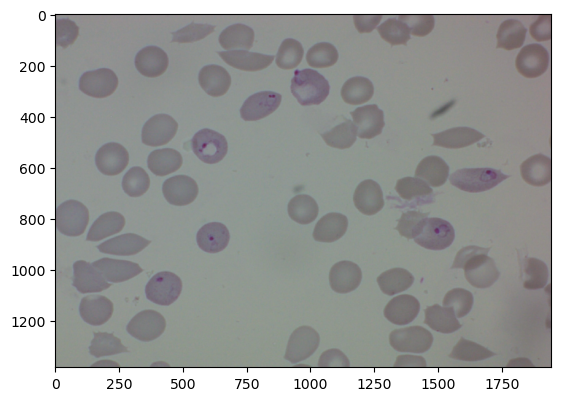

In [6]:
test_subject = 'e6a7743e-4040-40fa-b097-ca6874c469b7'
img = cv2.imread(dataset_prep[test_subject]["original_file"]).astype(float)
img_gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(float)
plt.imshow(img.astype(np.uint8))

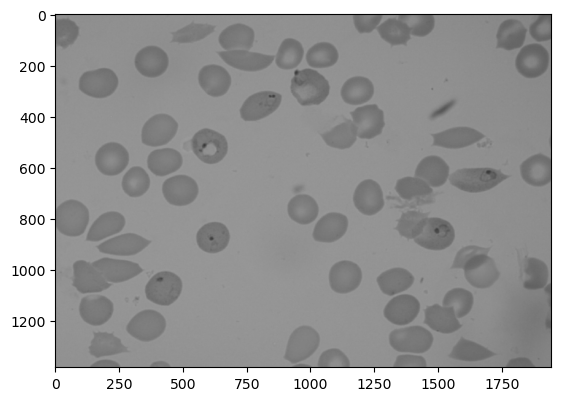

In [7]:
plt.imshow(img_gray.astype(np.uint8), cmap="gray", vmin=0, vmax=255)

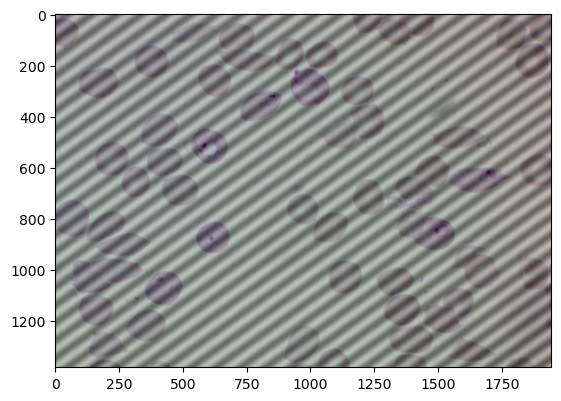

In [8]:
freq_x = 20
freq_y = 20
amp = 40
phase = 0

h, w = img_gray.shape[:2]
x, y = np.meshgrid(np.arange(w, dtype=float), np.arange(h, dtype=float))
freq_x_norm = freq_x / w
freq_y_norm = freq_y / h

noise_periodic = (amp * np.cos(2 * np.pi * (freq_x_norm * x + freq_y_norm * y) + phase)).astype(float)
#noise_periodic = np.clip(noise_periodic, None, 0)
noise_periodic_3 = cv2.merge([noise_periodic, noise_periodic, noise_periodic])
img_noise_periodic = cv2.add(img, noise_periodic_3)
img_noise_periodic = np.clip(img_noise_periodic, 0, 255)
plt.imshow(img_noise_periodic.astype(np.uint8))

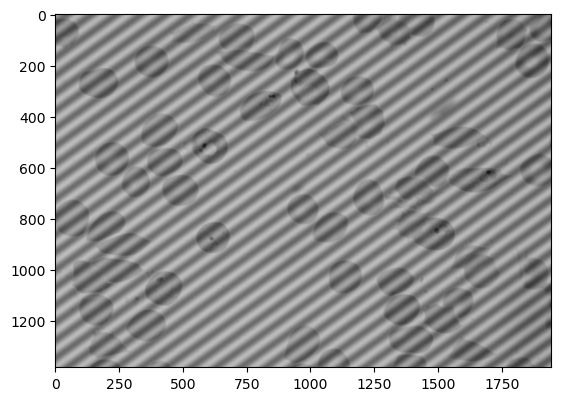

In [9]:
img_noise_periodic_gray = cv2.add(img_gray, noise_periodic)
img_noise_periodic_gray = np.clip(img_noise_periodic_gray, 0, 255)
plt.imshow(img_noise_periodic_gray.astype(np.uint8), cmap="gray", vmin=0, vmax=255)

In [10]:
mse_periodic = mean_squared_error(img_gray, img_noise_periodic_gray)
(ssim_periodic, diff_periodic) = structural_similarity(img_gray.astype(np.uint8), img_noise_periodic_gray.astype(np.uint8), full=True)
print(mse_periodic, ssim_periodic)

800.0 0.6461487493039628


### Edit old generator

In [11]:
class BloodCellsDataset(Dataset):

    def __init__(
        self,
        img_size: tuple[int, int], # (w, h)
        dataset_size: int,
        dataset_prep: dict,
        check_individual_coverage: bool = True, # Disable for faster generation
        p_background_solid: float = 0.5,
        p_cell_artificial: float = 0.5,
        min_cells_count: int = 40,
        max_cells_count: int = 100,
        min_cell_coverage: float = 0.25,
        gauss_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (0, 50),
        uniform_noise_params_ranges: tuple[tuple[float, float], tuple[float, float]] = (-100, 100),
        periodic_noise_params_ranges: tuple[tuple[float, float], tuple[float, float], tuple[float, float], tuple[float, float]] = (40, 40, 80, 0),
        p_noise_select: list[float] = [], # [gauss, uniform, periodic]
        noise_clamp: bool = True, # clamps resulting noisy image
        noise_grayscale: bool = True,
        mix_cells_datasets: bool = False,
    ):
        self.img_size = img_size
        assert(img_size[0] > 0 and img_size[1] > 0)
        self.dataset_size = dataset_size
        assert(dataset_size > 0)
        self.dataset_prep = dataset_prep
        self.min_cells_count = min_cells_count
        self.max_cells_count = max_cells_count
        assert(0 < min_cells_count <= max_cells_count)
        self.check_individual_coverage = check_individual_coverage
        self.p_background_solid = p_background_solid
        assert(0 <= p_background_solid <= 1)
        self.p_cell_artificial = p_cell_artificial
        assert(0 <= p_cell_artificial <= 1)
        self.min_cell_coverage = min_cell_coverage
        assert(0 <= min_cell_coverage <= 1)
        _gauss_noise_params_ranges = []
        for i in range(2):
            if not hasattr(gauss_noise_params_ranges[i], "__getitem__"):
                _gauss_noise_params_ranges.append((gauss_noise_params_ranges[i], gauss_noise_params_ranges[i]))
            else:
                _gauss_noise_params_ranges.append(gauss_noise_params_ranges[i])
            assert(_gauss_noise_params_ranges[i][0] <= _gauss_noise_params_ranges[i][1])
        _gauss_noise_params_ranges = tuple(_gauss_noise_params_ranges)
        assert(_gauss_noise_params_ranges[1][0] >= 0)
        assert(_gauss_noise_params_ranges[1][1] >= 0)
        self.gauss_noise_params_ranges = _gauss_noise_params_ranges
        _uniform_noise_params_ranges = []
        for i in range(2):
            if not hasattr(uniform_noise_params_ranges[i], "__getitem__"):
                _uniform_noise_params_ranges.append((uniform_noise_params_ranges[i], uniform_noise_params_ranges[i]))
            else:
                _uniform_noise_params_ranges.append(uniform_noise_params_ranges[i])
        _uniform_noise_params_ranges = tuple(_uniform_noise_params_ranges)
        self.uniform_noise_params_ranges = _uniform_noise_params_ranges
        _periodic_noise_params_ranges = []
        for i in range(4):
            if not hasattr(periodic_noise_params_ranges[i], "__getitem__"):
                _periodic_noise_params_ranges.append((periodic_noise_params_ranges[i], periodic_noise_params_ranges[i]))
            else:
                _periodic_noise_params_ranges.append(periodic_noise_params_ranges[i])
        _periodic_noise_params_ranges = tuple(_periodic_noise_params_ranges)
        self.periodic_noise_params_ranges = _periodic_noise_params_ranges
        noise_types_count = 3
        assert(len(p_noise_select) <= noise_types_count)
        assert(len(p_noise_select) == noise_types_count and sum(p_noise_select) == 1.0 or len(p_noise_select) < noise_types_count and sum(p_noise_select) <= 1.0)
        if len(p_noise_select) < noise_types_count:
            self.p_noise_select = p_noise_select + [(1.0 - sum(p_noise_select)) / (noise_types_count - len(p_noise_select))] * (noise_types_count - len(p_noise_select))
        else:
            self.p_noise_select = p_noise_select
        self.noise_clamp = noise_clamp
        self.noise_grayscale = noise_grayscale
        self.mix_cells_datasets = mix_cells_datasets

        self.generated_result_cells_dataset_keys = [None] * dataset_size
        self.generated_result_background_dataset_keys = [None] * dataset_size
        self.generated_results = []
        for i in range(dataset_size):
            self.generated_results.append(self.generate_result(i))

    def __len__(self) -> int:
        return self.dataset_size

    def __getitem__(self, item: int):
        assert(item >= 0 and item < self.__len__())
        return self.generated_results[item]

    def generate_result(self, index: int) -> tuple[torch.Tensor, torch.Tensor, int, str]:
        # Determine cells count
        cells_count = np.random.randint(self.min_cells_count, self.max_cells_count)
        # Select first cells dataset
        cells_dataset_key = self.choose_random_dataset()
        self.generated_result_cells_dataset_keys[index] = cells_dataset_key
        cells_dataset = self.dataset_prep[cells_dataset_key]
        cells_size_range = cells_dataset["cells_size_range"]
        # Generate background
        clean_img = self.select_background(index)
        # Init masks and imgs
        cells_mask = np.zeros((clean_img.shape[0], clean_img.shape[1]), clean_img.dtype)
        cells_img = np.zeros_like(clean_img)
        temp_img = np.zeros_like(cells_img)
        temp_mask_history = []
        # Begin
        actual_cells_count = 0
        for i in range(cells_count):
            for _max_attempts in range(999):
                # Reset temp
                temp_mask = np.zeros_like(cells_mask)
                temp_img.fill(0)
                # Select another cells dataset if mix_cells_datasets
                if self.mix_cells_datasets:
                    cells_dataset_key = self.choose_random_dataset()
                    cells_dataset = self.dataset_prep[cells_dataset_key]
                    cells_size_range = cells_dataset["cells_size_range"]
                # Select cell pos
                x = np.random.randint(cells_img.shape[1])
                y = np.random.randint(cells_img.shape[0])
                # select if generating artificial cell
                use_artificial_cell = bool(np.random.choice(2, p=[1-self.p_cell_artificial, self.p_cell_artificial]))

                if use_artificial_cell:
                    rad = np.random.randint(cells_size_range[0]//2, cells_size_range[1]//2)
                    cv2.circle(temp_mask, center=(x, y), radius=rad, color=255, thickness=-1)
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=cells_dataset["cells_color"].tolist(), thickness=-1)
                    stroke_color = 255 - cells_dataset["cells_color"]
                    cv2.circle(temp_img, center=(x, y), radius=rad, color=stroke_color.tolist(), thickness=3)
                else:
                    cell_index = np.random.randint(len(cells_dataset["cells"]))
                    cell_img = cells_dataset["cells"][cell_index]
                    _, cell_mask = cv2.threshold(cv2.cvtColor(cell_img, cv2.COLOR_BGR2GRAY), 3, 255, cv2.THRESH_BINARY)
                    temp_mask = self.overlay_image_center(temp_mask, cell_mask, x, y)
                    temp_img = self.overlay_image_center(temp_img, cell_img, x, y)
                # Insert generated cell
                temp_mask_without = cv2.bitwise_and(temp_mask, cv2.bitwise_not(cells_mask))
                coverage = np.count_nonzero(temp_mask_without) / np.count_nonzero(temp_mask)
                can_insert = coverage >= self.min_cell_coverage
                if self.check_individual_coverage and can_insert:
                    for prev_temp_mask in temp_mask_history:
                        if np.count_nonzero(cv2.bitwise_and(temp_mask, prev_temp_mask)) > 0:
                            temp_mask_without_ind = cv2.bitwise_and(temp_mask, cv2.bitwise_not(prev_temp_mask))
                            prev_temp_mask_without = cv2.bitwise_and(prev_temp_mask, cv2.bitwise_not(temp_mask))
                            # Check coverage
                            coverage = np.count_nonzero(temp_mask_without_ind) / np.count_nonzero(temp_mask)
                            prev_coverage = np.count_nonzero(prev_temp_mask_without) / np.count_nonzero(prev_temp_mask)
                            if coverage < self.min_cell_coverage or prev_coverage < self.min_cell_coverage:
                                can_insert = False
                                break
                if can_insert:
                    cells_img = self.add_image_with_mask(cells_img, temp_img, temp_mask_without)
                    cells_mask = self.add_image_with_mask(cells_mask, temp_mask, temp_mask_without)
                    if self.check_individual_coverage:
                        temp_mask_history.append(temp_mask)
                    actual_cells_count += 1
                    break
            else:
                print("Warning: loop ended earlier")
                break
        # add background
        clean_img = self.add_image_with_mask(clean_img, cells_img, cells_mask)
        # resize
        clean_img = cv2.resize(clean_img, dsize=(self.img_size[1], self.img_size[0])).astype(float)
        # create noisy
        noisy_img, noise_type = self.add_noise(clean_img)
        return (torch.FloatTensor(clean_img), torch.FloatTensor(noisy_img), actual_cells_count, noise_type)

    def choose_random_dataset(self) -> str:
        return np.random.choice(list(self.dataset_prep.keys()))

    def select_background(self, index: int) -> np.ndarray[np.uint8]:
        background_dataset_key = self.choose_random_dataset()
        self.generated_result_background_dataset_keys[index] = background_dataset_key
        background_dataset = self.dataset_prep[background_dataset_key]
        use_solid_background = bool(np.random.choice(2, p=[1-self.p_background_solid, self.p_background_solid]))
        clean_img = None
        if use_solid_background:
            clean_img = np.zeros_like(background_dataset["background"]) + background_dataset["background_color"]
        else:
            clean_img = background_dataset["background"].copy()
        return clean_img

    def add_noise(self, clean_img: np.ndarray[float]) -> np.ndarray[float]:
        def gauss_noise(noise_img):
            mean = np.random.uniform(
                self.gauss_noise_params_ranges[0][0],
                self.gauss_noise_params_ranges[0][1]
            )
            std = np.random.uniform(
                self.gauss_noise_params_ranges[1][0],
                self.gauss_noise_params_ranges[1][1]
            )
            cv2.randn(noise_img, mean, std)
        def uniform_noise(noise_img):
            low = np.random.uniform(
                self.uniform_noise_params_ranges[0][0],
                self.uniform_noise_params_ranges[0][1]
            )
            high = np.random.uniform(
                self.uniform_noise_params_ranges[1][0],
                self.uniform_noise_params_ranges[1][1]
            )
            cv2.randu(noise_img, low, high)
        def periodic_noise(noise_img):
            freq_x = np.random.uniform(
                self.periodic_noise_params_ranges[0][0],
                self.periodic_noise_params_ranges[0][1]
            )
            freq_y = np.random.uniform(
                self.periodic_noise_params_ranges[1][0],
                self.periodic_noise_params_ranges[1][1]
            )
            amp = np.random.uniform(
                self.periodic_noise_params_ranges[2][0],
                self.periodic_noise_params_ranges[2][1]
            )
            phase = np.random.uniform(
                self.periodic_noise_params_ranges[3][0],
                self.periodic_noise_params_ranges[3][1]
            )
            h, w = noise_img.shape[:2]
            x, y = np.meshgrid(np.arange(w, dtype=float), np.arange(h, dtype=float))
            freq_x_norm = freq_x / w
            freq_y_norm = freq_y / h
            noise_img[:] = (amp * np.cos(2 * np.pi * (freq_x_norm * x + freq_y_norm * y) + phase)).astype(float)
        noise_img = np.zeros((clean_img.shape[0], clean_img.shape[1]), float)
        noisy_img = None
        noise_dict = [
            {
                "name": "gauss",
                "func": gauss_noise,
            },
            {
                "name": "uniform",
                "func": uniform_noise,
            },
            {
                "name": "periodic",
                "func": periodic_noise,
            },
        ]
        use_noise = np.random.choice(len(noise_dict), p=self.p_noise_select)
        noise_type = noise_dict[use_noise]["name"]
        noise_dict[use_noise]["func"](noise_img)
        if not self.noise_grayscale:
            noise_img = cv2.merge([noise_img, noise_img, noise_img])
            noisy_img = cv2.add(clean_img, noise_img)
        else:
            clean_img_grayscale = cv2.cvtColor(clean_img.astype(np.uint8), cv2.COLOR_BGR2GRAY).astype(float)
            noisy_img = cv2.add(clean_img_grayscale, noise_img)
        if self.noise_clamp:
            noisy_img = np.clip(noisy_img, 0, 255)
        return (noisy_img, noise_type)

    @staticmethod
    def add_image_with_mask(a, b, mask):
        a1 = cv2.bitwise_and(a, a, mask=cv2.bitwise_not(mask))
        b1 = cv2.bitwise_and(b, b, mask=mask)
        return cv2.add(a1, b1)

    @staticmethod
    def overlay_image_center(background_img, foreground_img, center_x, center_y):
        # Get dimensions
        h2, w2 = background_img.shape[:2]
        h1, w1 = foreground_img.shape[:2]

        # Calculate top-left corner of foreground_img based on center position
        x1_start = center_x - w1 // 2
        y1_start = center_y - h1 // 2

        # Calculate boundaries for foreground_img placement
        x1_end = x1_start + w1
        y1_end = y1_start + h1

        # Calculate valid region in background_img (clamp to bounds)
        x2_start = max(0, x1_start)
        y2_start = max(0, y1_start)
        x2_end = min(w2, x1_end)
        y2_end = min(h2, y1_end)

        # Calculate corresponding region in foreground_img
        x1_crop_start = max(0, -x1_start)
        y1_crop_start = max(0, -y1_start)
        x1_crop_end = x1_crop_start + (x2_end - x2_start)
        y1_crop_end = y1_crop_start + (y2_end - y2_start)

        # Create a copy to avoid modifying original
        result = background_img.copy()

        # Only overlay if there's a valid overlap region
        if x2_end > x2_start and y2_end > y2_start:
            # Extract the valid region from foreground_img
            foreground_img_region = foreground_img[y1_crop_start:y1_crop_end, x1_crop_start:x1_crop_end]

            # Overlay onto background_img
            result[y2_start:y2_end, x2_start:x2_end] = foreground_img_region

        return result

In [12]:
blood_cells_dataset = BloodCellsDataset((1200, 1200), 1, dataset_prep, min_cells_count=90, p_noise_select=[0, 0, 1])

98


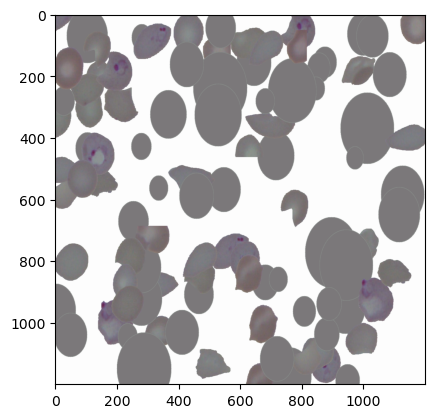

In [13]:
sample = list(blood_cells_dataset[0])
sample[0] = sample[0].numpy()
sample[1] = sample[1].numpy()
sample = tuple(sample)
print(sample[2])
plt.imshow(sample[0].astype(np.uint8))

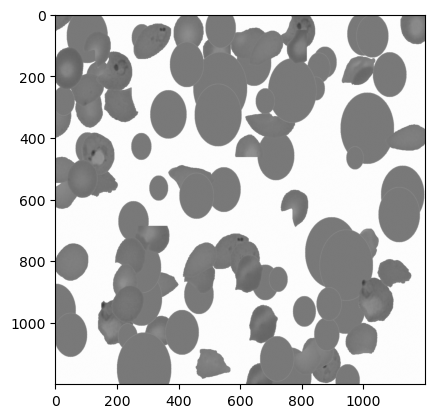

In [14]:
plt.imshow(cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY), cmap="gray", vmin=0, vmax=255)

periodic


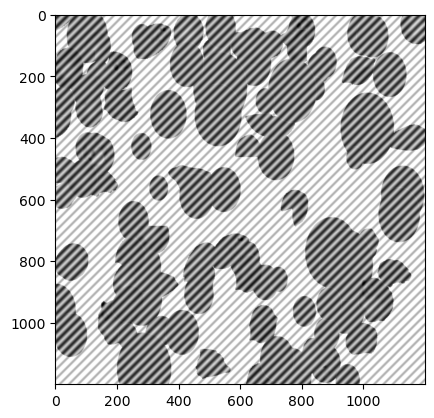

In [15]:
print(sample[3])
plt.imshow(sample[1].astype(np.uint8), cmap="gray", vmin=0, vmax=255)

In [16]:
sample_grayscale = (
    cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY),
    #cv2.cvtColor(sample[1].astype(np.uint8), cv2.COLOR_BGR2GRAY) # when noisy is RGB
    sample[1].astype(np.uint8) # when noisy is grayscale already
)
mse = mean_squared_error(sample_grayscale[0], sample_grayscale[1])
(ssim, diff) = structural_similarity(sample_grayscale[0], sample_grayscale[1], full=True)
print(mse, ssim)

2506.25826875 0.2375598695790132


## Denoising

### Demo

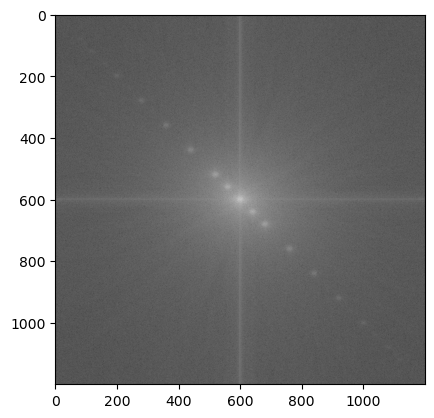

In [17]:
dft = cv2.dft(sample[1],flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
plt.imshow(magnitude_spectrum, cmap = 'gray')

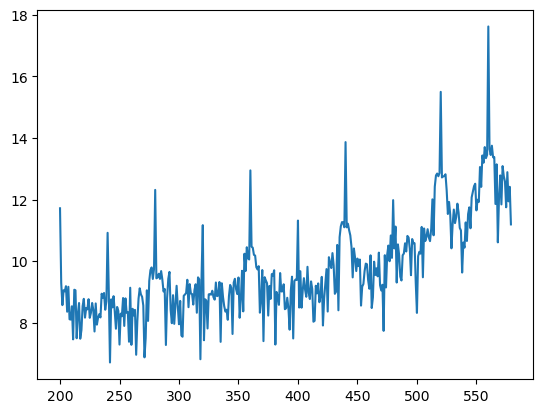

In [18]:
diag_vals = []
diag_i_bottom = 200
diag_i_range = range(diag_i_bottom, magnitude_spectrum.shape[0] // 2 - 20)
for i in diag_i_range:
    diag_vals.append(magnitude_spectrum[i, i])
plt.plot(diag_i_range, diag_vals)

5


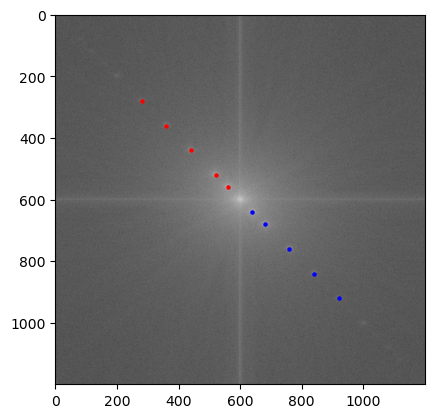

In [19]:
peaks, _ = find_peaks(diag_vals, prominence=4)
peaks = peaks + diag_i_bottom
print(len(peaks))
plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.scatter(peaks, peaks, s=5, c='red', marker='o')
plt.scatter(magnitude_spectrum.shape[0]-peaks, magnitude_spectrum.shape[0]-peaks, s=5, c='blue', marker='o')
plt.show()

#### Notch Filter

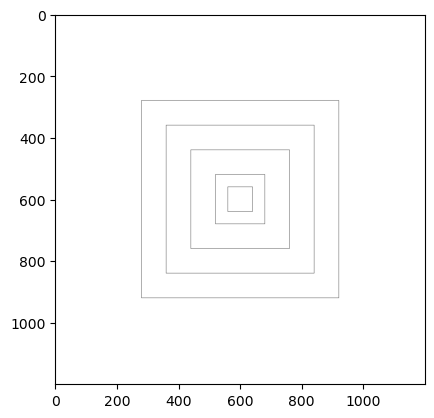

In [20]:
mask = np.ones((magnitude_spectrum.shape[0],magnitude_spectrum.shape[1],2),np.uint8)
for peak in peaks:
    mask = cv2.rectangle(mask, (peak, peak), (magnitude_spectrum.shape[0] - peak, magnitude_spectrum.shape[0] - peak), (0, 0), 1)
plt.imshow(mask[:,:,0], cmap = 'gray')

/tmp/ipykernel_9512/3825569316.py:2: RuntimeWarning: divide by zero encountered in log
  filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))


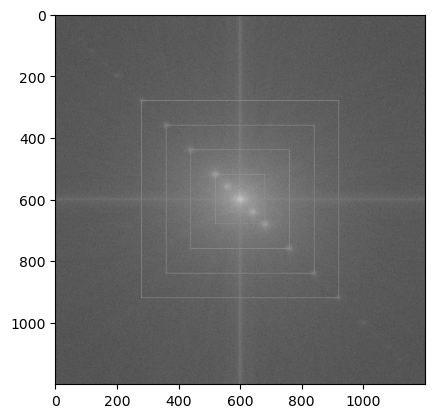

In [21]:
dft_shift_new = dft_shift*mask
filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))
plt.imshow(filtering_magn_res, cmap='gray')

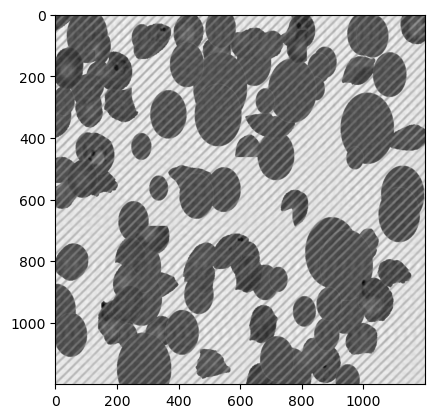

In [22]:
f_ishift = np.fft.ifftshift(dft_shift_new)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])
img_back = ((img_back - np.min(img_back)) / (np.max(img_back) - np.min(img_back)) * 255).astype(np.uint8)
plt.imshow(img_back, cmap = 'gray')

In [23]:
mse = mean_squared_error(sample_grayscale[0], img_back)
(ssim, diff) = structural_similarity(sample_grayscale[0], img_back, full=True)
print(mse, ssim)

1502.2727895833334 0.5080677739713005


#### Band reject filter

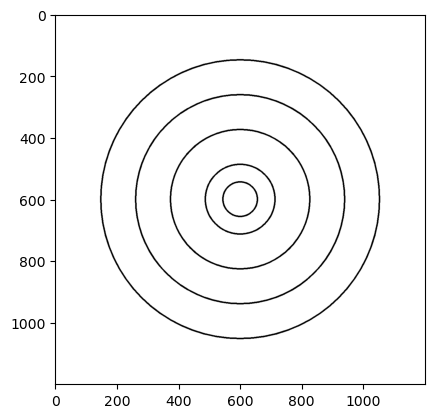

In [24]:
mask = np.ones((magnitude_spectrum.shape[0],magnitude_spectrum.shape[1],2),np.uint8)
mask_center = np.array([magnitude_spectrum.shape[0] // 2, magnitude_spectrum.shape[0] // 2])
for peak in peaks:
    mask = cv2.circle(mask, mask_center, int(np.linalg.norm(mask_center - np.array([peak, peak]))), (0, 0), 3)
plt.imshow(mask[:,:,0], cmap = 'gray')

/tmp/ipykernel_9512/3825569316.py:2: RuntimeWarning: divide by zero encountered in log
  filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))


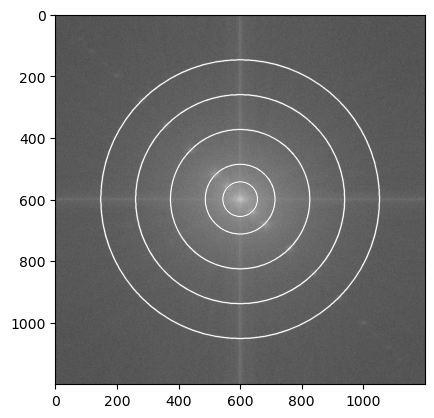

In [25]:
dft_shift_new = dft_shift*mask
filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))
plt.imshow(filtering_magn_res, cmap='gray')

0 255


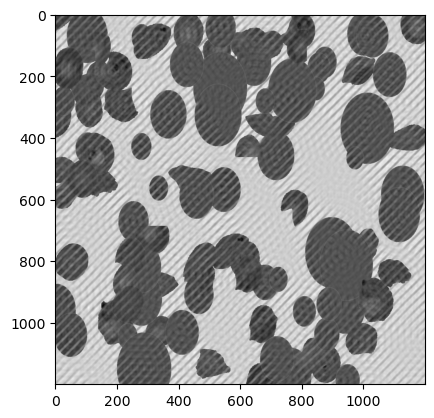

In [26]:
f_ishift = np.fft.ifftshift(dft_shift_new)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])
img_back = ((img_back - np.min(img_back)) / (np.max(img_back) - np.min(img_back)) * 255).astype(np.uint8)
plt.imshow(img_back, cmap = 'gray')
print(np.min(img_back), np.max(img_back))

In [27]:
mse = mean_squared_error(sample_grayscale[0], img_back)
(ssim, diff) = structural_similarity(sample_grayscale[0], img_back, full=True)
print(mse, ssim)

2031.6527145833334 0.570586175933205


### Actual thing

In [28]:
test_images = 10
denoising_dataset = BloodCellsDataset((1200, 1200), test_images, dataset_prep, min_cells_count=90, p_noise_select=[0, 0, 1])

In [29]:
def my_filter(img, mask_gen):
    dft = cv2.dft(img.astype(float),flags = cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))
    diag_vals = []
    diag_i_bottom = 200
    diag_i_range = range(diag_i_bottom, magnitude_spectrum.shape[0] // 2 - 20)
    for i in diag_i_range:
        diag_vals.append(magnitude_spectrum[i, i])
    peaks, _ = find_peaks(diag_vals, prominence=4)
    peaks = peaks + diag_i_bottom
    mask = np.ones((magnitude_spectrum.shape[0],magnitude_spectrum.shape[1],2),np.uint8)
    mask_gen(mask, peaks)
    dft_shift_new = dft_shift*mask
    filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))
    f_ishift = np.fft.ifftshift(dft_shift_new)
    img_back = cv2.idft(f_ishift)
    img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])
    img_back = ((img_back - np.min(img_back)) / (np.max(img_back) - np.min(img_back)) * 255).astype(np.uint8)
    return img_back
def notch_filter(img):
    def mask_gen(mask, peaks):
        for peak in peaks:
            mask = cv2.rectangle(mask, (peak, peak), (mask.shape[0] - peak, mask.shape[0] - peak), (0, 0), 1)
    return my_filter(img, mask_gen)
def band_reject_filter(img):
    def mask_gen(mask, peaks):
        mask_center = np.array([mask.shape[0] // 2, mask.shape[0] // 2])
        for peak in peaks:
            mask = cv2.circle(mask, mask_center, int(np.linalg.norm(mask_center - np.array([peak, peak]))), (0, 0), 3)
    return my_filter(img, mask_gen)

In [30]:
base_metrics = {
    "mse": [],
    "ssim": [],
}
denoise_results = {
    "Notch Filter": {
        "mse": [],
        "ssim": [],
    },
    "Band Reject Filter": {
        "mse": [],
        "ssim": [],
    }
}
for img_ind in range(test_images):
    sample = list(denoising_dataset[img_ind])
    sample[0] = sample[0].numpy()
    sample[1] = sample[1].numpy()
    sample = tuple(sample)
    img_gray = cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY)
    img_noisy_gray = sample[1].astype(np.uint8)
    assert(len(img_noisy_gray.shape) == 2)
    base_metrics["mse"].append(mean_squared_error(img_gray, img_noisy_gray))
    base_metrics["ssim"].append(structural_similarity(img_gray, img_noisy_gray, full=False))
    for name, f in (("Notch Filter", notch_filter), ("Band Reject Filter", band_reject_filter)):
        res = f(img_noisy_gray)
        denoise_results[name]["mse"].append(mean_squared_error(img_gray, res))
        denoise_results[name]["ssim"].append(structural_similarity(img_gray, res, full=False))


/tmp/ipykernel_9512/4239123583.py:15: RuntimeWarning: divide by zero encountered in log
  filtering_magn_res = np.log(cv2.magnitude(dft_shift_new[:,:,0],dft_shift_new[:,:,1]))


In [31]:
print(
    f"Base mean: " +
    f"mse={np.mean(base_metrics["mse"])}, " +
    f"ssim={np.mean(base_metrics["ssim"])}"
)
for key, value in denoise_results.items():
    print(
        f"{key} mean: " +
        f"mse={np.mean(value["mse"])}, " + 
        f"ssim={np.mean(value["ssim"])}"
    )

Base mean: mse=2162.8737260416665, ssim=0.2698086757411183
Notch Filter mean: mse=664.1867344444445, ssim=0.6276401178585147
Band Reject Filter mean: mse=1011.1850696527778, ssim=0.6546466027313084


# Wavelet

Сжатие данных при помощи вейвлет-преобразования.
1. Исходное изображение в оттенках серого кодируется к текстовом файле попиксельной записью интенсивности. RLE: каждое значение хранится парой чисел: (количество нулей перед ним, само значение)
2. Реализовать вейвлет -преобразование Хаара.
3. Удалить высокочастотные составляющие с низкими детализирующими коэффициентами. (OLD: Удалить нули данных)
4. Закодировать данные при помощи RLE алгоритма.
5. Сохранить получившиеся данные.
6. Определить степень сжатия (среднюю для набора изображений). Отношение объема файла до/после сжатия.

## Demo

In [32]:
blood_cells_dataset = BloodCellsDataset((1024, 1024), 1, dataset_prep, p_background_solid=1, min_cells_count=90)

94


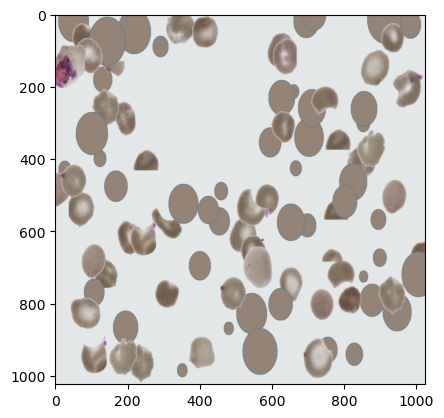

In [33]:
sample = list(blood_cells_dataset[0])
sample[0] = sample[0].numpy()
sample[1] = sample[1].numpy()
sample = tuple(sample)
print(sample[2])
plt.imshow(sample[0].astype(np.uint8))

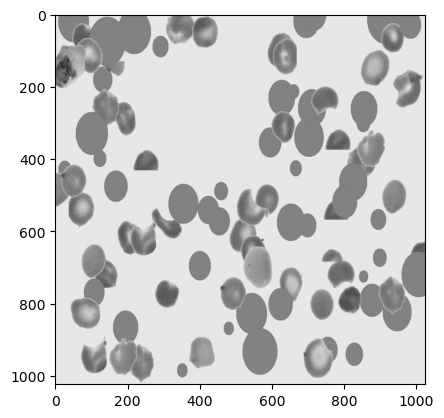

In [34]:
sample_grayscale = cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY)
plt.imshow(sample_grayscale, cmap="gray", vmin=0, vmax=255)

In [35]:
background_color = dataset_prep[blood_cells_dataset.generated_result_background_dataset_keys[0]]["background_color"]
background_color_gray = cv2.cvtColor(np.array([[background_color]], dtype=np.uint8), cv2.COLOR_BGR2GRAY)[0, 0]
background_color_gray

np.uint8(231)

In [36]:
def my_rle_encoding(filename, img: np.array, background: int=np.uint8(0))->int:
    with open(filename, "w") as f:
        f.write(f"{img.shape[0]} {img.shape[1]} {background}")
        flat_img = img.flatten()
        background_count = 0
        for i in range(flat_img.shape[0]):
            if (flat_img[i] == background).all():
                background_count += 1
                continue
            else:
                f.write(f" {background_count} {flat_img[i]}")
                background_count = 0
    return os.path.getsize(filename)
def my_rle_decoding(filename)->np.array:
    with open(filename, "r") as f:
        data = f.read().split(" ")
        shape = list(map(int, data[:2]))
        background = np.uint8(data[2])
        img = np.full(shape=shape[0] * shape[1], fill_value=background, dtype=np.uint8)
        data = data[3:]
        assert(len(data) % 2 == 0)
        i = 0
        for data_i in range(0, len(data), 2):
            i += int(data[data_i])
            img[i] = np.uint8(data[data_i+1])
            i += 1
        return img.reshape(shape)


Filesize=6278194
(1024, 1024)
0.0


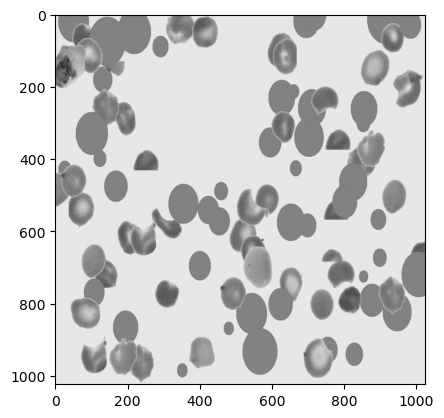

In [39]:
filesize = my_rle_encoding("lab3/wavelet_pre.txt", sample_grayscale, 0)
print(f"Filesize={filesize}")
restored_sample_grayscale = my_rle_decoding("lab3/wavelet_pre.txt")
print(restored_sample_grayscale.shape)
print(mean_squared_error(sample_grayscale, restored_sample_grayscale))
plt.imshow(restored_sample_grayscale, cmap="gray", vmin=0, vmax=255)

In [ ]:
def is_power_of_2(x: int):
    return x > 0 and (x & (x - 1)) == 0
def create_wavelet(img: np.array)->list[list[np.array]]:
    assert(is_power_of_2(img.shape[0]))
    assert(is_power_of_2(img.shape[1]))
    assert(len(img.shape) == 2)
    img_flat = img.flatten()
    evens = img_flat[0::2].astype(int)
    odds = img_flat[1::2].astype(int)
    res = [[(evens + odds) // 2, (evens - odds) // 2]]
    for i in range(int(math.log2(img_flat.shape[0])) - 1):
        evens = res[-1][0][0::2]
        odds = res[-1][0][1::2]
        res.append([(evens + odds) // 2, (evens - odds) // 2])
    return res
def restore_wavelet(wavelet: list[list[np.array]])->np.array:
    res = np.zeros((wavelet[0][0].shape[0] * 2,), dtype=int)
    res[0] = wavelet[-1][0][0] + wavelet_data[-1][1][0]
    res[1] = wavelet[-1][0][0] - wavelet_data[-1][1][0]
    sz = 2
    for i in range(len(wavelet) - 2, -1, -1):
        res_old = np.copy(res[:sz])
        c = wavelet[i][1]
        sz *= 2
        res[0:sz:2] = res_old + c
        res[1:sz:2] = res_old - c
    return res.astype(np.uint8)

19.740363121032715


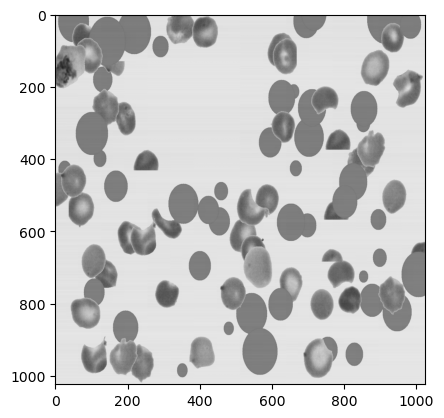

In [41]:
wavelet_data = create_wavelet(sample_grayscale)
restored_sample_grayscale = restore_wavelet(wavelet_data).reshape(sample_grayscale.shape)
print(mean_squared_error(sample_grayscale, restored_sample_grayscale))
plt.imshow(restored_sample_grayscale, cmap="gray", vmin=0, vmax=255)

In [42]:
def wavelet_compress(wavelet_data: list[list[np.array]], detail_threshold: int = 1):
    for w in wavelet_data:
        d = w[1]
        d[np.abs(d) <= detail_threshold] = 0

58.9436674118042


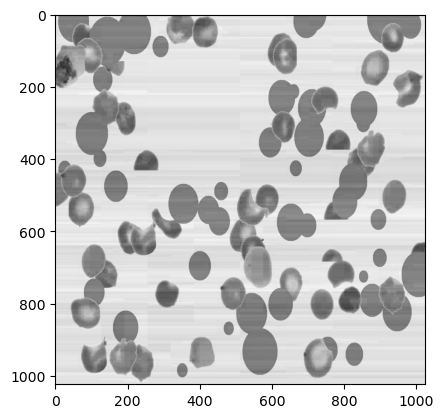

In [ ]:
wavelet_data = create_wavelet(sample_grayscale)
wavelet_compress(wavelet_data, detail_threshold=3)
compressed_sample_grayscale = restore_wavelet(wavelet_data).reshape(sample_grayscale.shape)
print(mean_squared_error(sample_grayscale, compressed_sample_grayscale))
plt.imshow(compressed_sample_grayscale, cmap="gray", vmin=0, vmax=255)

In [52]:
filesize_compressed = my_rle_encoding("lab3/wavelet_after.txt", compressed_sample_grayscale, 0)
print(f"Filesize_compressed={filesize_compressed}")

Filesize_compressed=6273160


In [53]:
filesize / filesize_compressed

1.0008024663805801

## Actual thing

In [54]:
test_images = 10
compression_dataset = BloodCellsDataset((1024, 1024), test_images, dataset_prep, p_background_solid=1, min_cells_count=90)

In [60]:
filesizes = []
filesizes_compressed = []
temp_filename = "lab3/temp_wavelet.txt"
for img_ind in range(test_images):
    sample = list(compression_dataset[img_ind])
    sample[0] = sample[0].numpy()
    img_gray = cv2.cvtColor(sample[0].astype(np.uint8), cv2.COLOR_BGR2GRAY)
    filesizes.append(my_rle_encoding(temp_filename, img_gray, 0))
    img_gray_wavelet = create_wavelet(img_gray)
    wavelet_compress(img_gray_wavelet, 3)
    img_gray_compressed = restore_wavelet(img_gray_wavelet).reshape(img_gray.shape)
    filesizes_compressed.append(my_rle_encoding(temp_filename, img_gray_compressed, 0))
os.remove(temp_filename)
filesizes = np.array(filesizes)
filesizes_compressed = np.array(filesize_compressed)
print(np.mean(filesizes / filesizes_compressed))

0.9710722187860663
